# 🧠 Modeling Phase — Multiclass Classification

### **Overview**
We train and evaluate machine learning models to predict **failure types** for machines.  
The dataset is imbalanced, so SMOTE is used to balance the classes.

**Steps Covered:**
1. Prepare Data & Encode Target
2. Handle Class Imbalance (SMOTE)
3. Train Random Forest
4. Train XGBoost
5. Evaluate Models


## 📌 Loading the Preprocessed Dataset

After completing all preprocessing steps (handling missing values, outlier removal, feature scaling, and PCA) in the data preprocessing notebook, we saved the final cleaned dataset as:

``preprocessed_smart_data.csv``

In this modeling notebook, we simply load the processed file instead of repeating the entire preprocessing pipeline:




In [2]:
import pandas as pd

hd_clean = pd.read_csv("preprocessed_smart_data.csv")
print("Loaded processed dataset:", hd_clean.shape)


Loaded processed dataset: (98538, 32)


In [3]:
# Check for NaN values in the dataset
nan_count = hd_clean.isna().sum()
print("Columns with NaN values:\n", nan_count[nan_count > 0])

Columns with NaN values:
 temp_diff                  1
vibration_diff             1
pressure_diff              1
vibration_ma              19
vibration_std             19
temperature_roc            1
vibration_roc              1
pressure_roc               1
humidity_roc               1
energy_consumption_roc     1
dtype: int64


In [4]:
# If there are any NaNs, drop the rows
hd_clean = hd_clean.dropna()
print("Shape after dropping NaN rows:", hd_clean.shape)

Shape after dropping NaN rows: (98519, 32)


## Prepare Data & Encode Target

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
features = [
    'temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption',
    'temp_roll_mean', 'vibration_roll_mean', 'pressure_roll_mean',
    'temp_diff', 'vibration_diff', 'pressure_diff',
    'vibration_zscore', 'temp_zscore', 'vibration_ma', 'vibration_std',
    'temperature_roc', 'vibration_roc', 'pressure_roc', 'humidity_roc', 'energy_consumption_roc'
]

# Target column
y_class = hd_clean['failure_type']

# Encode target for multiclass classification
le = LabelEncoder()
y_encoded = le.fit_transform(y_class)

# Features
X = hd_clean[features]

# Encode categorical features
X = pd.get_dummies(X.join(hd_clean[['machine_id']]), drop_first=True)

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


## 2️⃣ Handle Class Imbalance
- The dataset is imbalanced across failure types.
- SMOTE (Synthetic Minority Oversampling Technique) is used to balance the training data.


In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


## 3️⃣ Train Random Forest
- Use `RandomForestClassifier` with 300 trees.  
- `class_weight='balanced'` is used to handle class imbalance.


In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf_clf.fit(X_train_res, y_train_res)


RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

## Random Forest — Base Model Evaluation

- Evaluate the Random Forest model on the test set.
- Metrics: Accuracy, F1-score (macro & weighted), Confusion Matrix, Classification Report.


In [18]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd

class_names = ['Minor failure', 'Normal operation', 'Mechanical failure', 'Electrical failure', 'Sensor failure']


y_pred_rf = rf_clf.predict(X_test)


acc_rf = accuracy_score(y_test, y_pred_rf)
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro')
f1_weighted_rf = f1_score(y_test, y_pred_rf, average='weighted')
cm_rf = confusion_matrix(y_test, y_pred_rf)


print("===== Random Forest Evaluation =====")
print(f"Accuracy: {acc_rf}")
print(f"F1 Macro: {f1_macro_rf}")
print(f"F1 Weighted: {f1_weighted_rf}")


cm_df = pd.DataFrame(cm_rf, index=class_names, columns=class_names)
print("\nConfusion Matrix:\n", cm_df)


print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, target_names=class_names))


===== Random Forest Evaluation =====
Accuracy: 0.91336784409257
F1 Macro: 0.19408106744988618
F1 Weighted: 0.8778514828750893

Confusion Matrix:
                     Minor failure  Normal operation  Mechanical failure  \
Minor failure                   0               200                   0   
Normal operation               14             17993                  26   
Mechanical failure              0               390                   0   
Electrical failure              0               385                   0   
Sensor failure                  0               613                   0   

                    Electrical failure  Sensor failure  
Minor failure                        0               0  
Normal operation                    23              52  
Mechanical failure                   1               1  
Electrical failure                   2               1  
Sensor failure                       1               2  

Classification Report:
                     precision    rec

# 🔹 Counting Samples per Class






In [7]:
import pandas as pd

# Count number of samples per class
class_counts = pd.Series(y_train).value_counts()
print(class_counts)


1    72433
4     2463
2     1569
3     1550
0      800
Name: count, dtype: int64


# 🔹 Balancing Training Data Using SMOTE (Multiclass)

### Explanation:

- **SMOTE (Synthetic Minority Oversampling Technique)** is a method to handle **class imbalance** by creating synthetic samples for the minority classes.  
- It is particularly useful in **multiclass classification** problems where some classes have very few samples compared to others.  
- After applying SMOTE, the dataset becomes **balanced**, meaning all classes have roughly the same number of samples.  
- This helps the model:
  - Avoid bias toward majority classes
  - Learn better patterns for minority classes
  - Improve metrics such as recall, F1-score, and overall classification performance  

### Example Outcome:

- Before SMOTE, the dataset might look like this:


In [8]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE for multiclass
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

# Check new distribution
import pandas as pd
print(pd.Series(y_train_bal).value_counts())


1    72433
3    72433
4    72433
2    72433
0    72433
Name: count, dtype: int64


# 🔹 Training Multiclass XGBoost on Balanced Data

### Explanation:

- **Model**: `XGBClassifier` from XGBoost library  
- **Objective**: `'multi:softmax'`  
  - Used for **multiclass classification**  
  - Directly predicts the class labels (0, 1, 2, …)
- **num_class**: `len(set(y_train_bal))`  
  - Automatically sets the number of classes in the dataset
- **eval_metric**: `'mlogloss'`  
  - Multiclass logarithmic loss, used to evaluate the model during training
- **random_state**: `42`  
  - Ensures reproducibility of results
- **use_label_encoder**: `False`  
  - Avoids deprecation warning in recent XGBoost versions




In [9]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(set(y_train_bal)),
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False
)

xgb_model.fit(X_train_bal, y_train_bal)


c:\Users\user\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:02:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=5, ...)

# 🔹 Classification Report After Applying SMOTE




In [10]:
from sklearn.metrics import classification_report

y_pred = xgb_model.predict(X_test)
print("===== Classification Report After SMOTE =====")
print(classification_report(y_test, y_pred))


===== Classification Report After SMOTE =====
              precision    recall  f1-score   support

           0       0.02      0.06      0.03       200
           1       0.92      0.85      0.88     18108
           2       0.02      0.05      0.03       392
           3       0.02      0.04      0.03       388
           4       0.02      0.03      0.02       616

    accuracy                           0.78     19704
   macro avg       0.20      0.20      0.20     19704
weighted avg       0.85      0.78      0.81     19704



# What This Code Does: Balancing Classes

This code is all about **fixing class imbalance** in your dataset before training a model. Here’s what happens:

1. **Combine Features and Target**  
   - The features (`X_scaled`) and labels (`y_encoded`) are put together in one DataFrame for easier processing.

2. **Identify Majority and Minority Classes**  
   - The most frequent class is called the *majority class*.  
   - All other less frequent classes are called *minority classes*.

3. **Downsample the Majority Class**  
   - Reduce the number of samples in the majority class (keep only a portion) to avoid bias.

4. **Upsample the Minority Classes**  
   - Increase the number of samples in minority classes by duplicating some samples so that they have more weight in training.

5. **Combine Everything**  
   - Merge the downsampled majority class with the upsampled minority classes to create a **balanced dataset**.

6. **Separate Features and Labels**  
   - Split the balanced dataset back into features (`X_balanced`) and labels (`y_balanced`) ready for training.  
   - Print the new class distribution to verify it is now more balanced.

**Result:** Your dataset is now balanced, which helps machine learning models train better and avoid bias towards the majority class.


In [ ]:
from sklearn.utils import resample
from collections import Counter
import pandas as pd

# ===== Use columns after get_dummies =====
X_df = pd.get_dummies(X, drop_first=True)  # X is the original DataFrame before scaling
X_scaled = scaler.fit_transform(X_df)      # Apply scaling

# Merge X_scaled with y_encoded in a temporary DataFrame
df = pd.DataFrame(X_scaled, columns=X_df.columns)
df['target'] = y_encoded

# Separate classes
df_majority = df[df['target'] == 1]  # Normal operation (majority class)
df_minority = df[df['target'] != 1]  # All other classes (minority classes)

# Downsample the majority class
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=int(len(df_majority) * 0.5),  # Example: half of the samples
    random_state=42
)

# Upsample the minority classes
df_minority_upsampled = pd.DataFrame()
for cls in df_minority['target'].unique():
    df_cls = df_minority[df_minority['target'] == cls]
    df_cls_upsampled = resample(
        df_cls,
        replace=True,
        n_samples=int(len(df_cls) * 3),  # Example: triple the samples
        random_state=42
    )
    df_minority_upsampled = pd.concat([df_minority_upsampled, df_cls_upsampled])

# Combine them to get a balanced dataset
df_balanced = pd.concat([df_majority_downsampled, df_minority_upsampled])

# Separate features and target
X_balanced = df_balanced.drop('target', axis=1).values
y_balanced = df_balanced['target'].values

print("New class distribution:", Counter(y_balanced))


New class distribution: Counter({np.int64(1): 45270, np.int64(4): 9237, np.int64(2): 5883, np.int64(3): 5814, np.int64(0): 3000})


## 4️⃣ Train XGBoost
- Use `XGBClassifier` with 300 trees and `mlogloss` as eval metric.
- Disable `use_label_encoder` for recent versions of XGBoost.


In [15]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(n_estimators=300, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_clf.fit(X_balanced, y_balanced)


c:\Users\user\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:14:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

## XGBoost — Base Model Evaluation

- Evaluate the XGBoost model on the test set.


In [16]:
y_pred_xgb = xgb_clf.predict(X_test)

print("===== XGBoost Classification Report =====")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

===== XGBoost Classification Report =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       200
           1       0.99      1.00      0.99     18108
           2       0.99      0.82      0.89       392
           3       0.98      0.83      0.90       388
           4       0.97      0.80      0.88       616

    accuracy                           0.99     19704
   macro avg       0.98      0.89      0.93     19704
weighted avg       0.99      0.99      0.98     19704

Confusion Matrix:
 [[  199     1     0     0     0]
 [    1 18082     4     6    15]
 [    0    72   320     0     0]
 [    0    66     0   322     0]
 [    0   122     0     0   494]]


## 5️⃣ Train LightGBM

- Use **LGBMClassifier** for multiclass classification.  
- Parameters:
  - `n_estimators=300`  
  - `learning_rate=0.1`  
  - `max_depth=7`  
  - `random_state=42`  
- Training is done on **resampled training data** (after SMOTE).


In [53]:
from lightgbm import LGBMClassifier

# Initialize LightGBM classifier
lgbm_clf = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=7,
    random_state=42
)

# Train on SMOTE-resampled data
lgbm_clf.fit(X_train_res, y_train_res)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035999 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1540
[LightGBM] [Info] Number of data points in the train set: 362230, number of used features: 9
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(max_depth=7, n_estimators=300, random_state=42)

## LightGBM — Base Model Evaluation

- Evaluate the LightGBM model on the test set.


In [54]:
# Evaluate LightGBM
y_pred_lgbm = lgbm_clf.predict(X_test)

acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
f1_macro_lgbm = f1_score(y_test, y_pred_lgbm, average='macro')
f1_weighted_lgbm = f1_score(y_test, y_pred_lgbm, average='weighted')
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

print("===== LightGBM Evaluation =====")
print(f"Accuracy: {acc_lgbm}")
print(f"F1 Macro: {f1_macro_lgbm}")
print(f"F1 Weighted: {f1_weighted_lgbm}")
print("\nConfusion Matrix:\n", cm_lgbm)
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgbm))


===== LightGBM Evaluation =====
Accuracy: 0.9213517353359042
F1 Macro: 0.3731999053448959
F1 Weighted: 0.9270034745681688

Confusion Matrix:
 [[   42    14    57    38    49]
 [   65 17755    90    84   118]
 [   71    23   100    86   112]
 [   62    16    94    87   129]
 [   99    29   170   144   174]]

Classification Report:
               precision    recall  f1-score   support

           0       0.12      0.21      0.16       200
           1       1.00      0.98      0.99     18112
           2       0.20      0.26      0.22       392
           3       0.20      0.22      0.21       388
           4       0.30      0.28      0.29       616

    accuracy                           0.92     19708
   macro avg       0.36      0.39      0.37     19708
weighted avg       0.93      0.92      0.93     19708



# 🔍 Hyperparameter Tuning & Best Model Selection (Simplified)

### 1️⃣ Overview
- Tune hyperparameters for **Random Forest, XGBoost, and LightGBM** using **`RandomizedSearchCV`** with `n_iter=10`.
- Faster and lighter version suitable for Colab.
- Evaluate all tuned models on the **test set**.
- Compare metrics (F1-macro) and select the **best-performing model**.
- Save the best model as a **Pickle file** (`best_model_machine_fail.pkl`).

---

### 2️⃣ Step 1: Randomized Hyperparameter Tuning
- Use **RandomizedSearchCV** instead of GridSearchCV.
- Limit the number of iterations and parameter ranges to reduce runtime.
- Train each model on the **SMOTE-resampled training data**.

---

### 3️⃣ Step 2: Evaluate Tuned Models
- Evaluate each tuned model on the test set.
- Metrics: **Accuracy, F1-score (macro & weighted), Confusion Matrix, Classification Report**.
- This helps to identify the best-performing model.

---

### 4️⃣ Step 3: Select Best Model
- Compare the F1-macro of all three models.
- Select the model with the highest F1-macro as the **best model**.

---

### 5️⃣ Step 4: Save Best Model
- Save the selected best model as a **Pickle file** for future use.
- Filename: `best_model_machine_fail.pkl`


# 🔹 Random Forest — Randomized Hyperparameter Tuning

- Tune Random Forest hyperparameters using `RandomizedSearchCV`.
- n_iter=10 for faster execution.
- Evaluate the best Random Forest model later.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Parameter grid for Random Forest
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced"]
}

# Randomized Search
rf_rand = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42
)
rf_rand.fit(X_train_res, y_train_res)

# Train best model
best_rf = RandomForestClassifier(**rf_rand.best_params_, random_state=42)
best_rf.fit(X_train_res, y_train_res)

print("✅ Random Forest tuning completed. Best params:", rf_rand.best_params_)


# 🔹 XGBoost — Randomized Hyperparameter Tuning

- Tune XGBoost hyperparameters using `RandomizedSearchCV`.
- n_iter=10 for faster execution.


In [ ]:
from xgboost import XGBClassifier

xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_rand = RandomizedSearchCV(
    XGBClassifier(objective="multi:softprob", eval_metric="mlogloss", random_state=42),
    xgb_params,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42
)
xgb_rand.fit(X_train_res, y_train_res)

best_xgb = XGBClassifier(
    **xgb_rand.best_params_,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)
best_xgb.fit(X_train_res, y_train_res)

print("✅ XGBoost tuning completed. Best params:", xgb_rand.best_params_)


# 🔹 LightGBM — Randomized Hyperparameter Tuning

- Tune LightGBM hyperparameters using `RandomizedSearchCV`.
- n_iter=10 for faster execution.


In [ ]:
from lightgbm import LGBMClassifier

lgbm_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 7],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [20, 31]
}

lgbm_rand = RandomizedSearchCV(
    LGBMClassifier(random_state=42),
    lgbm_params,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42
)
lgbm_rand.fit(X_train_res, y_train_res)

best_lgbm = LGBMClassifier(**lgbm_rand.best_params_, random_state=42)
best_lgbm.fit(X_train_res, y_train_res)

print("✅ LightGBM tuning completed. Best params:", lgbm_rand.best_params_)


# 🔹 Evaluate Tuned Models & Select Best Model

- Evaluate **Random Forest, XGBoost, and LightGBM** after hyperparameter tuning.
- Metrics: Accuracy, F1-score (macro & weighted), Confusion Matrix, Classification Report.
- Select the **best-performing model** based on **F1-macro**.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Function to evaluate a model
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)

    print(f"===== {name} Report =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\n")

    return f1_macro

# Evaluate each tuned model individually
rf_f1 = evaluate_model(best_rf, X_test, y_test, "Random Forest")
xgb_f1 = evaluate_model(best_xgb, X_test, y_test, "XGBoost")
lgbm_f1 = evaluate_model(best_lgbm, X_test, y_test, "LightGBM")

# Compare and select the best model based on F1-macro
model_list = [(best_rf, "Random Forest"), (best_xgb, "XGBoost"), (best_lgbm, "LightGBM")]
best_model, best_model_name = max(model_list, key=lambda x: f1_score(y_test, x[0].predict(X_test), average="macro"))

print(f"🔥 Best Model Selected: {best_model_name}")


# 🔹 Compare Models & Select Best

- Evaluate **Random Forest, XGBoost, and LightGBM** on the test set.
- Compare **F1-macro** to select the best-performing model.


In [56]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Function to evaluate a model
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)

    print(f"===== {name} Evaluation =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\n")

    return f1_macro

# Evaluate all models
f1_rf = evaluate_model(rf_clf, X_test, y_test, "Random Forest")
f1_xgb = evaluate_model(xgb_clf, X_test, y_test, "XGBoost")
f1_lgbm = evaluate_model(lgbm_clf, X_test, y_test, "LightGBM")

# Compare F1-macro and select best model
model_list = [(rf_clf, "Random Forest", f1_rf),
              (xgb_clf, "XGBoost", f1_xgb),
              (lgbm_clf, "LightGBM", f1_lgbm)]

best_model, best_model_name, best_f1 = max(model_list, key=lambda x: x[2])

print(f"🔥 Best Model Selected: {best_model_name} with F1-macro: {best_f1:.4f}")


===== Random Forest Evaluation =====
Accuracy: 0.9235
F1 Macro: 0.3835
F1 Weighted: 0.9303

Confusion Matrix:
 [[   28     0    56    38    78]
 [   44 17727    78    81   182]
 [   43     0   108    93   148]
 [   42     0    94    79   173]
 [   53     1   150   153   259]]

Classification Report:
               precision    recall  f1-score   support

           0       0.13      0.14      0.14       200
           1       1.00      0.98      0.99     18112
           2       0.22      0.28      0.25       392
           3       0.18      0.20      0.19       388
           4       0.31      0.42      0.36       616

    accuracy                           0.92     19708
   macro avg       0.37      0.40      0.38     19708
weighted avg       0.94      0.92      0.93     19708



===== XGBoost Evaluation =====
Accuracy: 0.9224
F1 Macro: 0.3784
F1 Weighted: 0.9290

Confusion Matrix:
 [[   31     5    60    43    61]
 [   54 17738    79    91   150]
 [   59    11   108    93   121]
 [ 

# 🔹 Multiclass ROC & AUC for XGBoost

### Overview:

- **ROC (Receiver Operating Characteristic)** curve shows the trade-off between **True Positive Rate (Recall)** and **False Positive Rate** for each class.  
- **AUC (Area Under the Curve)** quantifies the overall ability of the model to discriminate between classes.  
- In **multiclass problems**, we compute ROC and AUC **for each class separately** using one-vs-rest strategy.

---

### Step 1: Binarize Test Labels

- Convert `y_test` into **one-hot encoding** to compute ROC for each class:



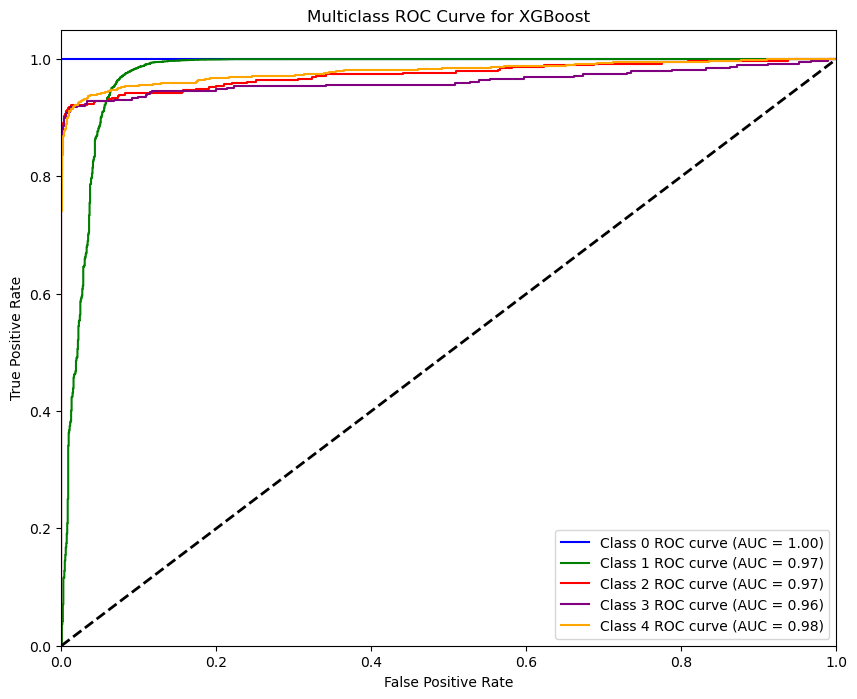

In [17]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# ===== Step 1: Binarize the test labels for multiclass ROC =====
# Converts y_test to one-hot encoding
y_test_bin = label_binarize(y_test, classes=range(len(set(y_balanced))))

# ===== Step 2: Predict class probabilities =====
y_prob = xgb_clf.predict_proba(X_test)  # shape: [n_samples, n_classes]

# ===== Step 3: Compute FPR, TPR, and AUC for each class =====
n_classes = y_test_bin.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# ===== Step 4: Plot ROC curves =====
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple', 'orange']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'Class {i} ROC curve (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve for XGBoost')
plt.legend(loc='lower right')
plt.show()


## Save Best Model

- Save the best-performing model as a Pickle file for deployment.
- Example filename: `best_model_failure_type.pkl`


In [18]:
import pickle

with open("best_model_failure_type.pkl", "wb") as f:
    pickle.dump(xgb_clf, f)

print("✅ XGBoost model saved as best_model_failure_type.pkl")


✅ XGBoost model saved as best_model_failure_type.pkl


# 🛠️ Final Insights for Milestone 3: Predictive Maintenance Model Development and Optimization

## 🎯 Objectives
- Build, train, and optimize the predictive maintenance model for forecasting equipment failures.

## 📝 Tasks

### 1️⃣ Model Selection
- Choose a suitable model for time-series forecasting based on the nature of the data:
  - **LSTM (Long Short-Term Memory networks)** 🧠: Good for sequential data and time-series predictions.
  - **Random Forest** 🌲: Robust to overfitting and can handle non-linear relationships in the data.
  - **XGBoost** ⚡: A powerful gradient boosting model for classification and regression tasks.
  - **LightGBM** 🌟: Efficient gradient boosting framework, fast training, handles large datasets and categorical features well.

### 2️⃣ Model Training
- Split the data into **training, validation, and test sets** to evaluate model performance effectively.
- Use **time-series cross-validation** ⏱️ to ensure the model generalizes well across different time periods and avoids overfitting.

### 3️⃣ Model Evaluation
- Evaluate the models using metrics such as:
  - **Precision** 🎯: Measures the accuracy of positive predictions (i.e., correctly predicting equipment failure).
  - **Recall** 🔍: Measures the ability to capture all true failures.
  - **F1-score** ⚖️: The harmonic mean of precision and recall, balancing the two.
  - **ROC-AUC** 📊: Measures the model’s ability to distinguish between failure and non-failure instances.

### 4️⃣ Model Optimization
- Fine-tune **hyperparameters** 🔧 using **Grid Search** or **Random Search** to improve model performance.
- Explore combining multiple models via **ensemble methods** 🤝 to boost prediction accuracy.

## 💡 Key Takeaways
- LSTM is ideal for sequential trends in sensor data.  
- Random Forest is robust for mixed-feature datasets with non-linear patterns.  
- XGBoost and LightGBM excel in boosting performance and handling large datasets.  
- Hyperparameter tuning and ensemble methods significantly improve prediction accuracy.  
- Time-series cross-validation ensures models generalize well across operational periods.  
